# Loan Prediction – Feature Engineering & Data Preprocessing
### AnalystLab Africa – Data Science Internship Programme
**Week 2: Feature Engineering & Data Preprocessing for Machine Learning**

Dataset: Loan Prediction Problem Dataset (614 applications, 13 variables)
Business objective: prepare the dataset to predict whether a loan application should be approved (`Loan_Status`).


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
COLORS = ["#4C72B0", "#DD8452"]


## Part 2 – Data Inspection

In [5]:
df = pd.read_csv("../data/raw/loan_prediction_raw.csv")
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [6]:
print("Shape:", df.shape)
df.info()

Shape: (614, 13)
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


**Missing values:**

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).loc[missing > 0]


,missing_count,missing_pct
Gender,13,2.1
Married,3,0.5
Dependents,15,2.4
Self_Employed,32,5.2
LoanAmount,22,3.6
Loan_Amount_Term,14,2.3
Credit_History,50,8.1


**Duplicate records:**

In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


**Summary statistics (numeric columns):**

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


**Inspection summary:**
- 614 loan applications, 13 columns.
- 7 columns have missing values: `Gender`, `Married`, `Dependents`, `Self_Employed`, `LoanAmount`, `Loan_Amount_Term`, `Credit_History`.
- No duplicate rows.
- `Loan_ID` is a unique identifier and carries no predictive value — it will be dropped.
- Target variable `Loan_Status` is imbalanced: about 69% approved (Y) vs 31% not approved (N).


## Part 3 – Feature Engineering & Data Preprocessing

### 3.1 Data Cleaning – Handling Missing Values

Strategy:
- Categorical columns (`Gender`, `Married`, `Dependents`, `Self_Employed`, `Credit_History`) → fill with the **mode**, since these are discrete/categorical in nature and the mode preserves the most common category.
- `LoanAmount` → fill with the **median**, since income-related numeric variables are usually right-skewed and the median is more robust to outliers than the mean.
- `Loan_Amount_Term` → fill with the **mode**, since it only takes a handful of discrete values (e.g. 360 months dominates).


In [10]:
df_clean = df.copy()

# Drop the identifier column - not useful for prediction
df_clean.drop(columns=["Loan_ID"], inplace=True)

# Categorical -> mode
for col in ["Gender", "Married", "Dependents", "Self_Employed", "Credit_History"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Numeric -> median / mode
df_clean["LoanAmount"] = df_clean["LoanAmount"].fillna(df_clean["LoanAmount"].median())
df_clean["Loan_Amount_Term"] = df_clean["Loan_Amount_Term"].fillna(df_clean["Loan_Amount_Term"].mode()[0])

print("Remaining missing values:", df_clean.isnull().sum().sum())


Remaining missing values: 0


**Removing duplicates (if any):**

In [11]:
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"Rows before: {before}, after: {len(df_clean)}")


Rows before: 614, after: 614


### 3.2 Correcting Data Types

In [12]:
# Dependents has a '3+' category - convert to numeric (3)
df_clean["Dependents"] = df_clean["Dependents"].replace("3+", 3).astype(int)

# Credit_History is categorical (0/1), not a true float
df_clean["Credit_History"] = df_clean["Credit_History"].astype(int)

df_clean.dtypes


Gender                   str
Married                  str
Dependents             int64
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History         int64
Property_Area            str
Loan_Status              str
dtype: object

### 3.3 Feature Engineering


In [ ]:
df_clean["TotalIncome"] = df_clean["ApplicantIncome"] + df_clean["CoapplicantIncome"]

df_clean.rename(columns={
    "ApplicantIncome": "Applicant_Income",
    "CoapplicantIncome": "Coapplicant_Income",
    "LoanAmount": "Loan_Amount",
}, inplace=True)

df_clean.head()

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1,Urban,Y,5849.0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1,Rural,N,6091.0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1,Urban,Y,3000.0
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1,Urban,Y,4941.0
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1,Urban,Y,6000.0


## Visualizations

### 1. Histogram – Applicant Income Distribution

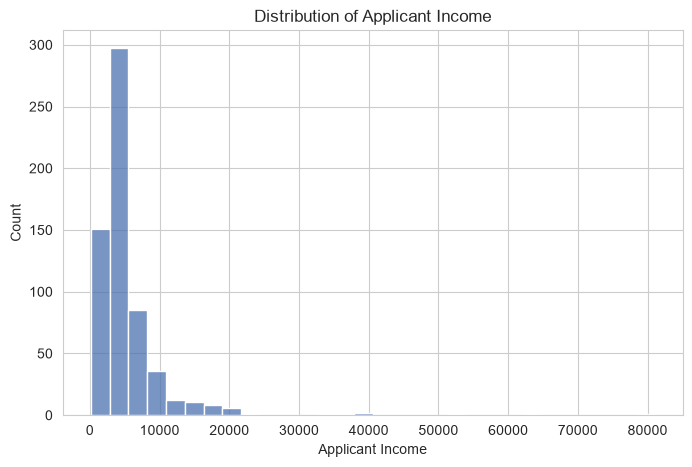

In [14]:
plt.figure()
sns.histplot(df_clean["Applicant_Income"], bins=30, color=COLORS[0])
plt.title("Distribution of Applicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Count")
plt.savefig("../visuals/hist_applicant_income.png", bbox_inches="tight")
plt.show()


**Interpretation:** Applicant income is heavily right-skewed, with most applicants earning under 10,000 and a long tail of high earners — a strong sign that scaling and outlier treatment will be needed.

### 2. Boxplot – Loan Amount Outliers

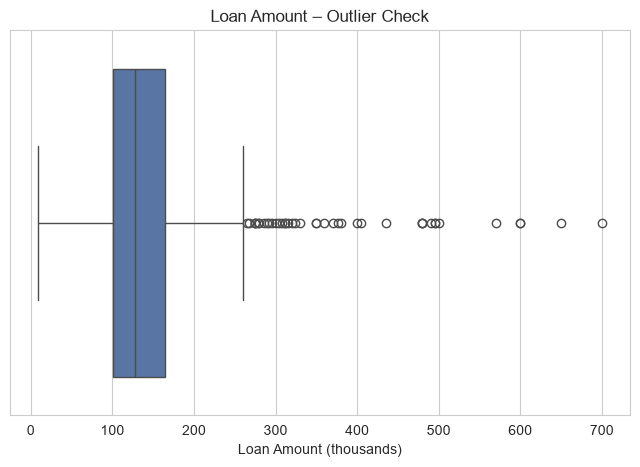

In [15]:
plt.figure()
sns.boxplot(x=df_clean["Loan_Amount"], color=COLORS[0])
plt.title("Loan Amount – Outlier Check")
plt.xlabel("Loan Amount (thousands)")
plt.savefig("../visuals/boxplot_loan_amount.png", bbox_inches="tight")
plt.show()


**Interpretation:** Several loan amounts sit well above the upper whisker, confirming the presence of outliers that should be capped rather than left untreated.

### 3. Count Plot – Loan Status by Credit History

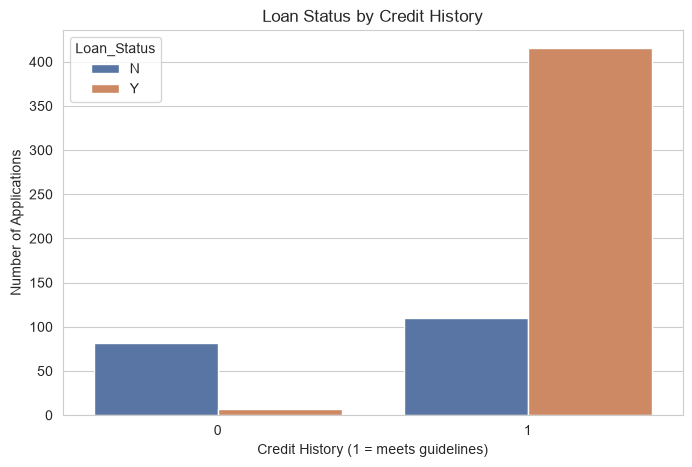

In [16]:
plt.figure()
sns.countplot(data=df_clean, x="Credit_History", hue="Loan_Status", palette=COLORS)
plt.title("Loan Status by Credit History")
plt.xlabel("Credit History (1 = meets guidelines)")
plt.ylabel("Number of Applications")
plt.savefig("../visuals/countplot_credit_history.png", bbox_inches="tight")
plt.show()


**Interpretation:** Credit history is clearly the strongest visible predictor — almost all approvals come from applicants with `Credit_History = 1`.

### 4. Count Plot – Loan Status by Property Area

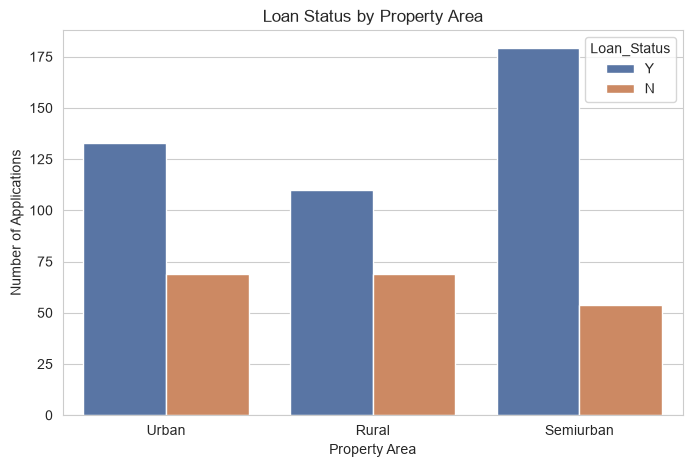

In [17]:
plt.figure()
sns.countplot(data=df_clean, x="Property_Area", hue="Loan_Status", palette=COLORS)
plt.title("Loan Status by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Number of Applications")
plt.savefig("../visuals/countplot_property_area.png", bbox_inches="tight")
plt.show()


**Interpretation:** Semiurban applicants are approved at a noticeably higher rate than urban or rural applicants.

### 5. Scatter Plot – Total Income vs Loan Amount

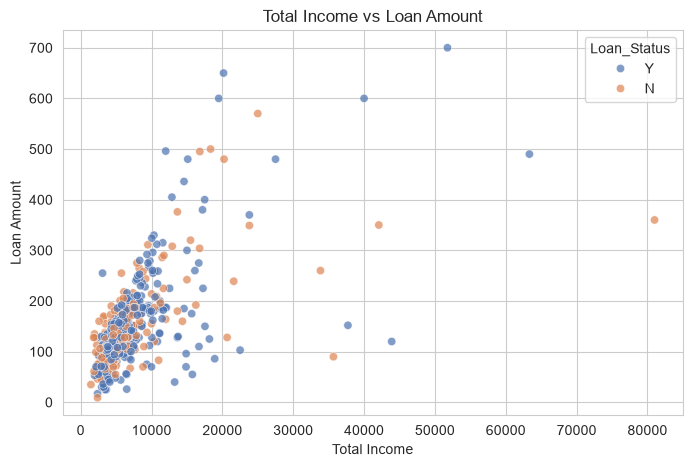

In [18]:
plt.figure()
sns.scatterplot(data=df_clean, x="TotalIncome", y="Loan_Amount", hue="Loan_Status", palette=COLORS, alpha=0.7)
plt.title("Total Income vs Loan Amount")
plt.xlabel("Total Income")
plt.ylabel("Loan Amount")
plt.savefig("../visuals/scatter_income_loanamount.png", bbox_inches="tight")
plt.show()


**Interpretation:** There is a mild positive relationship between income and loan amount, as expected, but approval doesn't visibly depend on this relationship alone — reinforcing that credit history matters more.

### 6. Correlation Heatmap

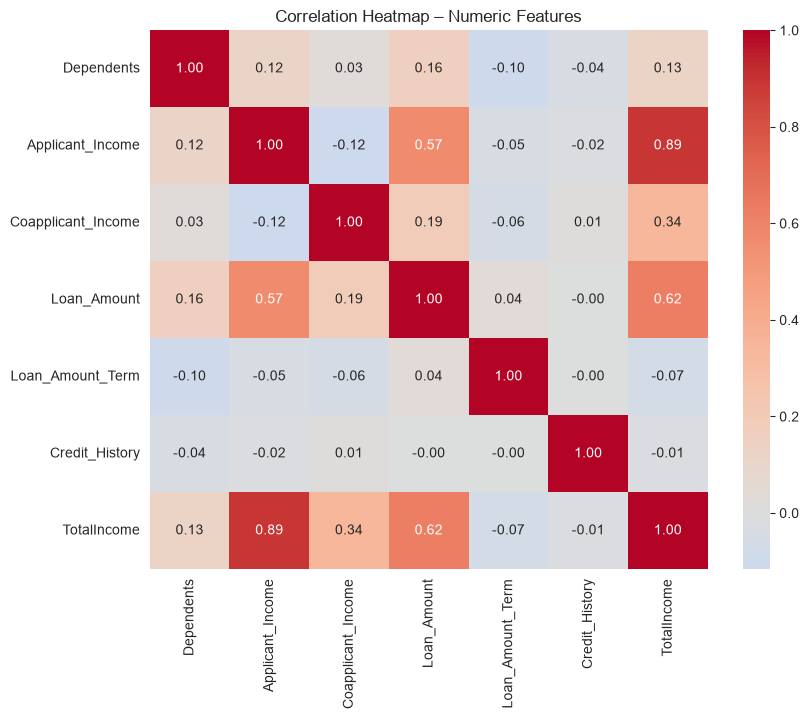

In [19]:
plt.figure(figsize=(9, 7))
numeric_df = df_clean.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap – Numeric Features")
plt.savefig("../visuals/correlation_heatmap.png", bbox_inches="tight")
plt.show()


**Interpretation:** `TotalIncome` is strongly correlated with `Applicant_Income` (as expected, since it's derived from it) and moderately with `Coapplicant_Income`. `Credit_History` shows the strongest correlation with the (numerically encoded) target further down this notebook.

## Outlier Detection & Handling (IQR Method)

Applied to `Applicant_Income`, `Coapplicant_Income`, `Loan_Amount`, and `TotalIncome`: values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are **capped** (winsorized) to the nearest boundary rather than removed, so we don't lose otherwise valid loan applications.


In [20]:
def cap_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

for col in ["Applicant_Income", "Coapplicant_Income", "Loan_Amount", "TotalIncome"]:
    df_clean[col] = cap_outliers_iqr(df_clean[col])

df_clean[["Applicant_Income", "Coapplicant_Income", "Loan_Amount", "TotalIncome"]].describe().T


,count,mean,std,min,25%,50%,75%,max
Applicant_Income,614.0,4617.111564,2479.851729,150.0,2877.50,3812.5,5795.00,10171.250
Coapplicant_Income,614.0,1419.702231,1624.605892,0.0,0.00,1188.5,2297.25,5743.125
Loan_Amount,614.0,137.365635,55.779749,9.0,100.25,128.0,164.75,261.500
TotalIncome,614.0,6194.722590,2875.791920,1442.0,4166.00,5416.5,7521.75,12555.375


## Saving the Cleaned Dataset

This version has missing values handled, duplicates removed, data types corrected, and outliers capped — but categorical variables are still in their original (human-readable) form, and no scaling has been applied yet.


In [21]:
df_clean.to_csv("../data/processed/loan_cleaned.csv", index=False)
print("Saved: loan_cleaned.csv", df_clean.shape)


Saved: loan_cleaned.csv (614, 13)


## Feature Encoding

- **Label Encoding** for binary categorical variables (`Gender`, `Married`, `Education`, `Self_Employed`, `Loan_Status`) — appropriate here because each has exactly two categories, so a single 0/1 column captures the information without adding dimensionality.
- **One-Hot Encoding** for `Property_Area` — appropriate because it has 3 unrelated categories (Urban/Semiurban/Rural) with no natural order, so label encoding would wrongly imply a ranking between them.


In [22]:
df_ml = df_clean.copy()

# Label Encoding for binary categorical variables
label_cols = ["Gender", "Married", "Education", "Self_Employed", "Loan_Status"]
le = LabelEncoder()
for col in label_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

# One-Hot Encoding for Property_Area (3 categories, no order)
df_ml = pd.get_dummies(df_ml, columns=["Property_Area"], prefix="Area", drop_first=True)

df_ml.head()


,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,Area_Semiurban,Area_Urban
0,1,0,0,0,0,5849.0,0.0,128.0,360.0,1,1,5849.0,False,True
1,1,1,1,0,0,4583.0,1508.0,128.0,360.0,1,0,6091.0,False,False
2,1,1,0,0,1,3000.0,0.0,66.0,360.0,1,1,3000.0,False,True
3,1,1,0,1,0,2583.0,2358.0,120.0,360.0,1,1,4941.0,False,True
4,1,0,0,0,0,6000.0,0.0,141.0,360.0,1,1,6000.0,False,True


## Feature Scaling

Applied **StandardScaler** to the numeric income/amount columns. StandardScaler was chosen over MinMaxScaler because these variables have a wide range and (even after capping) some skew — standardizing to mean 0 / std 1 works better with the outlier-sensitive but skew-tolerant nature of the remaining values than squashing everything into a fixed [0,1] range.


In [23]:
numeric_cols = ["Applicant_Income", "Coapplicant_Income", "Loan_Amount", "Loan_Amount_Term", "TotalIncome"]
scaler = StandardScaler()
df_ml[numeric_cols] = scaler.fit_transform(df_ml[numeric_cols])

df_ml[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Applicant_Income,614.0,1.764784e-16,1.000815,-1.802831,-0.702070,-0.324724,0.475371,2.241532
Coapplicant_Income,614.0,9.257886e-17,1.000815,-0.874587,-0.874587,-0.142429,0.540601,2.663383
Loan_Amount,614.0,1.012581e-16,1.000815,-2.303171,-0.665939,-0.168041,0.491338,2.227252
Loan_Amount_Term,614.0,5.930833e-17,1.000815,-5.132498,0.273231,0.273231,0.273231,2.137276
TotalIncome,614.0,1.996232e-16,1.000815,-1.654013,-0.706023,-0.270832,0.461824,2.213595


## Part 4 – Feature Selection

Looking back at the correlation heatmap, `Applicant_Income` and `TotalIncome` are highly correlated (TotalIncome is derived from it), which introduces redundancy. Since `TotalIncome` also includes `Coapplicant_Income`, it captures more information about household ability to repay — so `Applicant_Income` and `Coapplicant_Income` are dropped in favour of keeping just `TotalIncome`.


In [24]:
corr_with_target = df_ml.corr(numeric_only=True)["Loan_Status"].sort_values(ascending=False)
corr_with_target


Loan_Status           1.000000
Credit_History        0.540556
Area_Semiurban        0.136540
Married               0.091478
Gender                0.017987
Coapplicant_Income    0.011983
Dependents            0.010118
TotalIncome           0.002220
Applicant_Income     -0.000442
Self_Employed        -0.003700
Loan_Amount_Term     -0.022549
Area_Urban           -0.043621
Loan_Amount          -0.047262
Education            -0.085884
Name: Loan_Status, dtype: float64

In [25]:
df_ml.drop(columns=["Applicant_Income", "Coapplicant_Income"], inplace=True)
df_ml.columns.tolist()


['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Loan_Amount',
 'Loan_Amount_Term',
 'Credit_History',
 'Loan_Status',
 'TotalIncome',
 'Area_Semiurban',
 'Area_Urban']

**Feature selection decisions:**
- Removed `Applicant_Income` and `Coapplicant_Income` (redundant with `TotalIncome`).
- Kept `Credit_History` — the strongest correlate of `Loan_Status` by a wide margin.
- Kept all remaining engineered/encoded features — none of them showed the same level of redundancy.


## Part 5 – Final Machine Learning Dataset

Summary of every preprocessing step applied to reach this final dataset:
1. Dropped `Loan_ID` (identifier, no predictive value).
2. Filled missing values (mode for categorical, median for `Loan_Amount`, mode for `Loan_Amount_Term`).
3. Removed duplicate rows (none found).
4. Corrected data types (`Dependents`, `Credit_History`).
5. Engineered `TotalIncome` from `Applicant_Income` + `Coapplicant_Income`.
6. Capped outliers using the IQR method on income/amount columns.
7. Label-encoded binary categorical variables.
8. One-hot encoded `Property_Area`.
9. Standard-scaled numeric columns.
10. Removed redundant/highly correlated features (`Applicant_Income`, `Coapplicant_Income`).

The dataset below is fully numeric, has no missing values, and is ready to be used for machine learning model training in Week 3.


In [26]:
df_ml.to_csv("../data/processed/loan_ml_ready.csv", index=False)
print("Saved: loan_ml_ready.csv", df_ml.shape)
df_ml.head()


Saved: loan_ml_ready.csv (614, 12)


,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,Area_Semiurban,Area_Urban
0,1,0,0,0,0,-0.168041,0.273231,1,1,-0.120316,False,True
1,1,1,1,0,0,-0.168041,0.273231,1,0,-0.036097,False,False
2,1,1,0,0,1,-1.280462,0.273231,1,1,-1.111808,False,True
3,1,1,0,1,0,-0.311579,0.273231,1,1,-0.436313,False,True
4,1,0,0,0,0,0.065209,0.273231,1,1,-0.067766,False,True


## Business Questions – Summary

1. **Most relevant features:** `Credit_History` (by far the strongest), `TotalIncome`, `Loan_Amount`, `Property_Area`, `Married`.
2. **Variables requiring encoding:** `Gender`, `Married`, `Education`, `Self_Employed`, `Loan_Status` (label encoding); `Property_Area` (one-hot encoding).
3. **Variables requiring scaling:** `Applicant_Income`/`TotalIncome`, `Coapplicant_Income`, `Loan_Amount`, `Loan_Amount_Term` — all wide-range numeric columns.
4. **Redundant/highly correlated features:** `Applicant_Income` and `Coapplicant_Income` were redundant with the engineered `TotalIncome` and were removed.
5. **Missing values & outliers:** missing values were imputed (mode/median depending on variable type); outliers in income/loan amount columns were capped using the IQR method rather than removed, to preserve sample size.
6. **Preprocessing techniques that improved quality:** missing value imputation, type correction, outlier capping, encoding, and scaling together turned a partially incomplete, mixed-type dataset into a clean, fully numeric one.
7. **Is the dataset ready for machine learning?** Yes — `loan_ml_ready.csv` has no missing values, all features are numeric, outliers are controlled, and redundant features have been removed.
